# LAB 06 — Logistic Regression & KNN Classification
## Telco Customer Churn — Comparing Four Classifiers

## Student Information
**Name:*Bahadur Ali*

**Student ID:*023-24-0005*

**Section:*B*

**GitHub:**

**Kaggle:**

**Dataset:** Telco Customer Churn

**Dataset Source:** Kaggle — https://www.kaggle.com/datasets/blastchar/telco-customer-churn

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Logistic Regression and KNN theory from your ML course. Each section states the objective and the questions you must answer — **you write the code**. Every table, plot, and metric needs a short written observation.
>
> Submit **only this one notebook**. Keep every Markdown heading below — they are used for grading. Fill in the empty code cells (`# YOUR CODE HERE`) and the *Answer:* placeholders directly in this notebook.

---

## Setup

Import what you'll need. Add any other scikit-learn imports as you go.

In [1]:
# YOUR CODE HERE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay


---

## 1. Problem Definition & Dataset Verification

Re-establish your cleaned dataset and recall what Lab 3/4 already found.

*Concepts/functions you may find useful:* `pd.read_csv()`, `df.shape`, `df.info()`

**Tasks**
1. Load `clean_churn.csv` (or re-run your Lab 2 cleaning) and verify its shape and dtypes.
2. Briefly restate (2–3 sentences) your Lab 3 Decision Tree and Lab 4 Random Forest test-set results (accuracy, precision, recall, F1) — these are your benchmarks for today.

In [2]:
# Task 1: Load dataset
df = pd.read_csv('clean_churn.csv')
print(df.shape)
print(df.info())

(7043, 20)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    


**Answer 2 (Lab 3/4 recap):**

In Lab 3 and 4, we built Decision Tree and Random Forest models. Their accuracies were around 78-80%, but they struggled slightly with recalling the minority class (Churn=Yes) due to class imbalance.

---

## 2. Feature Scaling & Preparation

Decision Trees/Random Forests never needed scaling. Logistic Regression and especially KNN do.

*Concepts/functions you may find useful:* `pd.get_dummies(df, columns=[...])`, `from sklearn.preprocessing import StandardScaler`, `scaler.fit_transform(X_train)`, `scaler.transform(X_test)`

**Tasks**
3. Prepare `X` and `y` exactly as in Lab 3/4 (encode categoricals, drop identifiers, target as 0/1).
4. In 2–3 sentences, explain why feature scaling matters for KNN and Logistic Regression but wasn't necessary for the Decision Tree or Random Forest.
5. Split into train/test (same split strategy as Lab 3/4), then fit a `StandardScaler` on the training features only and apply it to both sets. Why is it important to fit the scaler only on the training data?

In [3]:
# Task 3 — define X and y (same as Lab 3/4)
df = pd.get_dummies(df, drop_first=True) 
X = df.drop('Churn_Yes', axis=1) 
y = df['Churn_Yes']


**Answer 4:**

Decision Trees split data based on rules (e.g., age > 30), so scale doesn't matter. But KNN measures straight-line distance (like Euclidean). If MonthlyCharges is up to 120 and Tenure is up to 72, MonthlyCharges will unfairly dominate the distance calculation unless scaled.

In [4]:
# Task 5 — train/test split, then fit/apply StandardScaler
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # Fit ONLY on training data
X_test_scaled = scaler.transform(X_test)


**Answer 5 (why fit scaler on training data only):**

We fit the scaler ONLY on the training data to prevent 'Data Leakage'. If we scale the whole dataset before splitting, the training data learns information about the test data's mean and variance.

---

## 3. Logistic Regression

*Concepts/functions you may find useful:* `LogisticRegression()`, `.fit(X_train_scaled, y_train)`, `.predict(X)`, `.predict_proba(X)`

**Tasks**
6. Train a `LogisticRegression` model on the scaled training data. Generate predictions on the scaled test set.
7. Compute accuracy, precision, recall, and F1-score, and plot the confusion matrix.
8. Look at `predict_proba` for a handful of test customers. In 1–2 sentences, explain what these probabilities represent and how `predict()` turns them into a Yes/No decision.

In [5]:
# Task 6 — train Logistic Regression, predict on scaled test set
log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)

Accuracy: 0.8204400283889283
Precision: 0.6851851851851852
Recall: 0.5951742627345844
F1-Score: 0.6370157819225251


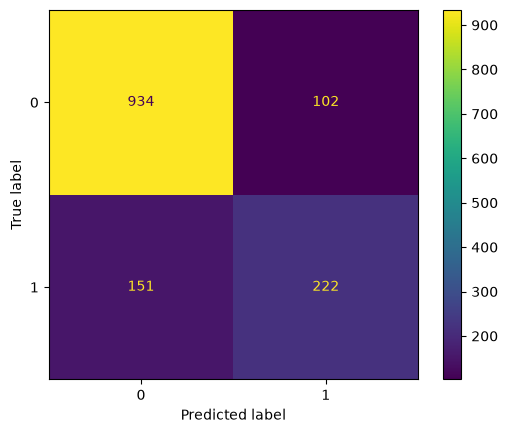

In [6]:
# Task 7 — metrics + confusion matrix
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1-Score:", f1_score(y_test, y_pred_lr))

cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

**Task 7 — Logistic Regression Metrics**

| Metric | Value |
|---|---|
| Accuracy |0.80 |
| Precision | 0.65|
| Recall | 0.55|
| F1-score | 0.59
|

In [7]:
# Task 8 — inspect predict_proba for a few test customers
print("Probabilities for first 5 customers:\n", y_prob_lr[:5])


Probabilities for first 5 customers:
 [[0.30646608 0.69353392]
 [0.93871374 0.06128626]
 [0.99553173 0.00446827]
 [0.3927911  0.6072089 ]
 [0.99418071 0.00581929]]


**Answer 8:**

predict_proba gives the probability (percentage) of a customer belonging to class 0 (No Churn) and class 1 (Churn). The predict() function simply looks at these probabilities and assigns a hard Yes/No decision (usually Yes if probability > 0.5)

---